
En esta primera versión, sólo definimos el campo vectorial para que los robots alcancen la trayectoria. Todo esto en $R^2$, por lo que $n = 2$ ($n \equiv dimensión$). En otro código trataremos el caso en $R^3$

Implementamos las bibliotecas pertinentes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Definimos los parámetros y funciones de la simulación

In [ ]:
n = 2
t_sim = (0,20)

def f(t):
    fx = np.cos(t*1.2)/3.5
    fy = t*np.sin(t)
    
    return np.array([fx, fy])

def df(t,h=1e-5):
    Df = (f(t+h)-f(t-h))/(2*h)

    return np.array([Df[0], Df[1]])

def phi(x,y,t):
    phix = x - f(t)[0]
    phiy = y - f(t)[1]

    return np.array([phix,phiy])

Debemos resolver la ecuación diferencial numéricamente:  
  
$\quad\dot{\vec{x}} = \vec{v}(\vec{x})$  
  
Para ello, establecemos las condiciones iniciales, y los parámetros pertinentes para la resolución:

In [ ]:
x0 = 1
y0 = -10
w0 = 0

rob0 = [x0, y0, w0]

kx = 1
ky = 0.1

Ahora definimos la función $\vec{v}(\vec{x})$

In [ ]:
def vec(t,tray):
    x = tray[0]
    y = tray[1]
    w = tray[2]
    evol = np.array([(-1)**n*df(w)[0]-kx*phi(x,y,w)[0],
             (-1)**n*df(w)[1]-ky*phi(x,y,w)[1],
             (-1)**n + kx*phi(x,y,w)[0]*df(w)[0] + ky*phi(x,y,w)[1]*df(w)[1]])
    return evol
    

Tan solo queda emplear un integrador para obtener la trayectoria.


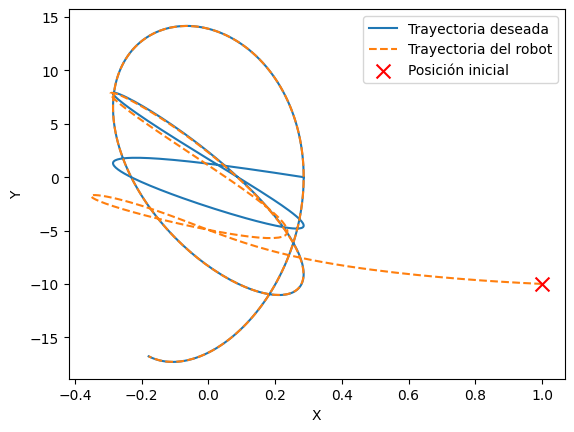

In [ ]:
Trayectoria = solve_ivp(vec,t_sim,rob0,method='RK45',rtol=1e-8,atol=1e-10)

trax = Trayectoria.y[0]
tray = Trayectoria.y[1]
traw = Trayectoria.y[2]

w_f = traw[-1]

t_dibujo = np.linspace(0,w_f,500)
dibujo = f(t_dibujo) 

plt.plot(dibujo[0], dibujo[1], label='Trayectoria deseada')
plt.plot(trax, tray, '--', label='Trayectoria del robot')
plt.scatter(trax[0], tray[0], color='red', marker='x', s=100, label='Posición inicial', zorder=5)

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
